In [30]:
import numpy as np
from matplotlib import pyplot as plt
import torch as tc
import torch.nn as nn
import torch.optim as optim

In [80]:
class LatentRNN(nn.Module):
    
    def __init__(self, obs_dim, latent_dim, dropout=0.0):
        
        super(LatentRNN, self).__init__()
        self.obs_dim = obs_dim
        self.latent_dim = latent_dim
        self.activation = nn.Tanh()

        # Input to hidden state
        self.input_to_hidden = nn.Linear(obs_dim, latent_dim, bias=True)
        
        # From previous hidden state
        self.hidden_to_hidden = nn.Linear(latent_dim, latent_dim, bias=False)
        
        # Hidden state to output
        self.hidden_to_output = nn.Linear(latent_dim, obs_dim, bias=True)

        # Optional dropout
        self.dropout = nn.Dropout(p=dropout)
        
    def forward(self, time_series, h0):

        seq_len, batch_size, _ = time_series.shape
        h = h0
        outputs = []

        for t in range(seq_len):
            x_t = time_series[t]  # Input
            h = self.activation(self.input_to_hidden(x_t) + self.hidden_to_hidden(h))  # Hidden state update
            h = self.dropout(h)
            x_hat = self.hidden_to_output(h)  # Predicted output
            outputs.append(x_hat)

        obs_output = tc.stack(outputs, dim=0)  # Stack outputs
        return obs_output, h

In [81]:
def train(model, learning_rate, hidden_size, epochs, moment=0, optimizer_function='ADAM',
          print_loss=False, batch_size=5, batch_sequence_length=15, minibatch=True, regularization_fn=None, alpha=0.0):

    model.train()
    
    # Select optimizer
    parameters = list(model.parameters())
    if optimizer_function == 'SGD':
        optimizer = optim.SGD(parameters, lr=learning_rate, momentum=moment)
    elif optimizer_function == 'ADAM':
        optimizer = optim.Adam(parameters, lr=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_function}")
    
    # Loss
    loss_function = nn.MSELoss()
    losses = []

    if print_loss:
        print(f"\nStarting training for {epochs} epochs...")
        print(f"Optimizer: {optimizer_function}, LR: {learning_rate}, Batch size: {batch_size}, Sequence length: {batch_sequence_length}")

    for epoch in range(epochs):
        # Initialize hidden state
        if minibatch:
            h0 = tc.rand(batch_size, hidden_size)
        else:
            h0 = tc.rand(1, 1, hidden_size)
        h = h0

        # Prepare sequences
        x = data[:-1]
        y = data[1:]

        # Create mini-batches
        if minibatch:
            X = tc.zeros(batch_sequence_length, batch_size, observation_size)
            Y = tc.zeros(batch_sequence_length, batch_size, observation_size)
            for j in range(batch_size):
                ind = tc.randint(0, len(x) - batch_sequence_length + 1, (1,)).item()
                X[:, j, :] = x[ind:ind + batch_sequence_length]
                Y[:, j, :] = y[ind:ind + batch_sequence_length]

        # Forward pass
        optimizer.zero_grad()
        if minibatch:
            obs_output, h = model(X, h)
            epoch_loss = loss_function(obs_output, Y)
        else:
            obs_output, h = model(x.unsqueeze(1), h)
            epoch_loss = loss_function(obs_output.squeeze(1).squeeze(1), y)

        # Add regularization
        if regularization_fn is not None:
            reg_term = regularization_fn(model, alpha)
            epoch_loss += reg_term

        # Backpropagation
        epoch_loss.backward()
        optimizer.step()

        losses.append(epoch_loss.item())

        if epoch % 10 == 0 and print_loss:
            print(f"Epoch: {epoch} loss {epoch_loss.item():.6f}")
    
    return model, losses

In [82]:
def generate_traj(model, prediction_length):
    
    model.eval()
    
    with tc.no_grad():
        # Initialize hidden state
        h = tc.rand(1, hidden_size)
        
        # Warm up hidden state
        warmup_input = data.unsqueeze(1)
        _, h = model(warmup_input, h)

        # Start generation
        input_ = data[0:1].unsqueeze(1)
        out, h = model(input_, h)
        
        # Initialize output
        predictions = tc.zeros(prediction_length, 1, observation_size)
        predictions[0] = out.squeeze(0)

        # Generate sequence
        for i in range(1, prediction_length):
            input_ = out
            out, h = model(input_, h)
            predictions[i] = out.squeeze(0)
    
    return predictions.squeeze()

In [83]:
def plot_prediction(model, prediction_length, title='Predictions'):
    
    predictions = generate_traj(model,prediction_length)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(predictions[:, 0],'--', label='dim 1 pred', linewidth=2)
    plt.plot(predictions[:, 1],'--', label='dim 2 pred', linewidth=2)
    plt.plot(data[:, 0], label='sin(t*π/10)', linewidth=2)
    plt.plot(data[:, 1], label='cos(t*π/10)', linewidth=2)
    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [84]:
# Load the sinusoidal data
data = tc.load('noisy_sinus.pt')
observation_size = data.shape[1]

/var/folders/8z/kcqff85n4_gd_f_zryqx22vc0000gn/T/ipykernel_11608/744993755.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = tc.load('noisy_sinus.pt')


2. a)

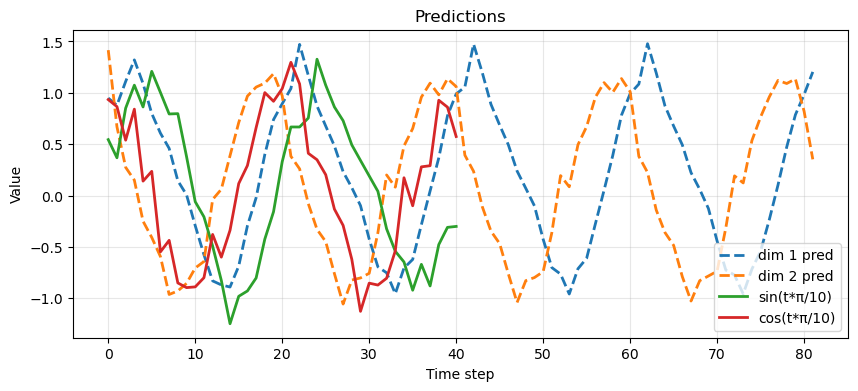

In [85]:
# Initialize the model
hidden_size = 40
observation_size = 2
model = LatentRNN(observation_size, hidden_size)

# Train
epochs = 2000
learning_rate = 0.01
model, losses = train(model, learning_rate, hidden_size, epochs)

# Plot prediction
prediction_length = 2 * data.shape[0]
plot_prediction(model, prediction_length)

We clearly see that with a hidden size of 40 there is overfitting. Now add L1 regularization:

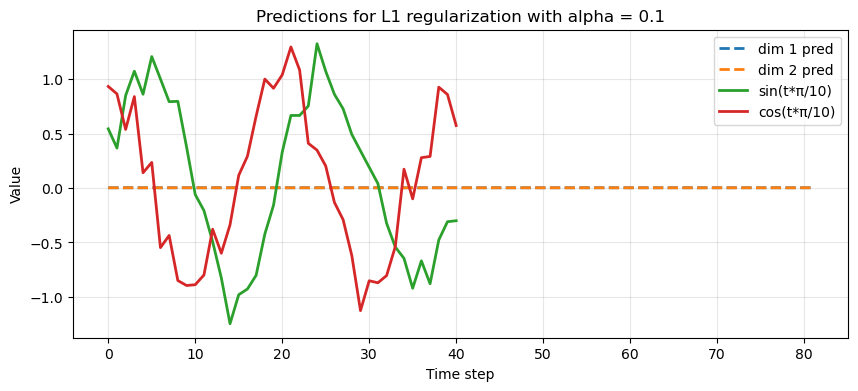

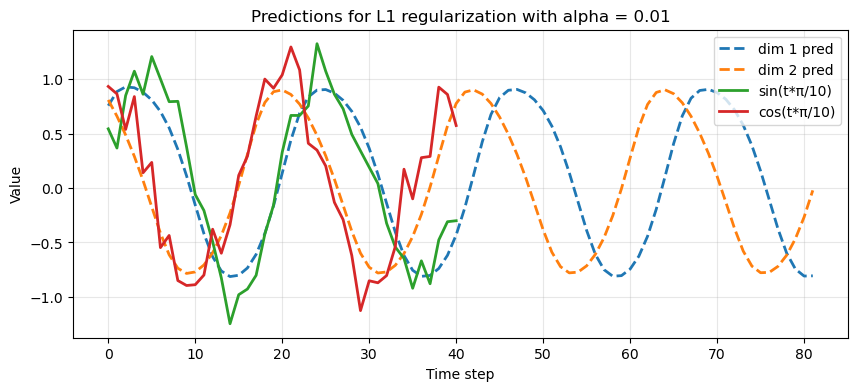

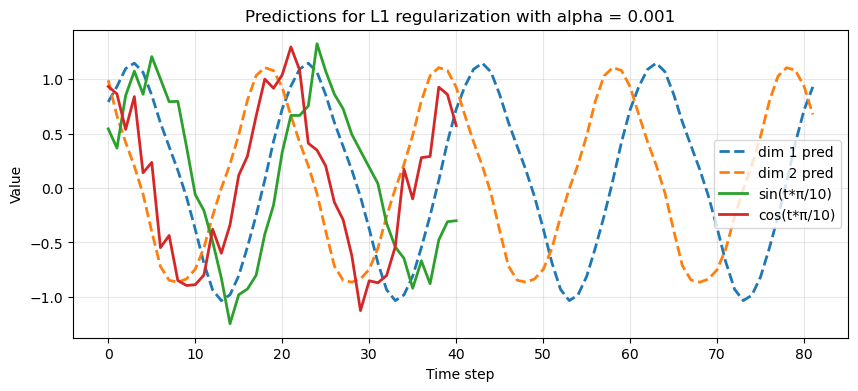

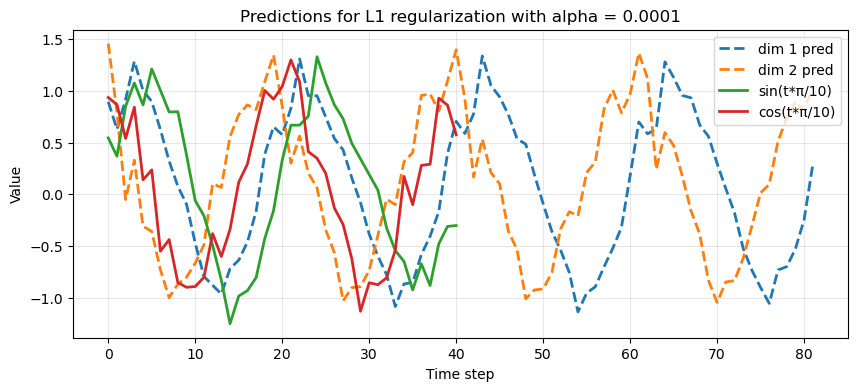

In [107]:
# L1 regularization function
def l1_reg(model, alpha):
    
    l1_reg = sum(param.abs().sum() for param in model.parameters())
    reg_term = alpha * l1_reg

    return reg_term

# Train for different alphas
alphas = [0.1, 0.01, 0.001, 0.0001]
for alpha in alphas:
    
    model = LatentRNN(observation_size, hidden_size)
    model, losses = train(model, learning_rate, hidden_size, epochs, regularization_fn = l1_reg, alpha=alpha)
    
    # Plot prediction
    prediction_length = 2 * data.shape[0]
    title = f'Predictions for L1 regularization with alpha = {alpha}'
    plot_prediction(model, prediction_length, title)

L1 regularization adds the sum of absolute values of the weights to the loss function. This pushes small weights towards zero. By driving parameters to zero, L1 removes less important connections so we have a sparse model. This reduces the risk of memorizing noise and discourages overfitting.

2. b)

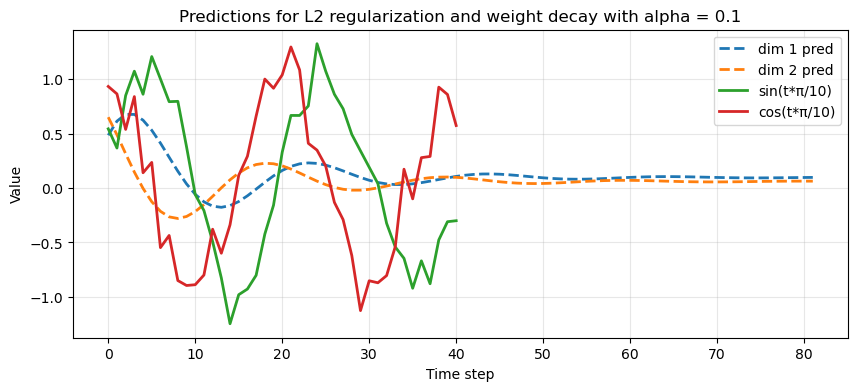

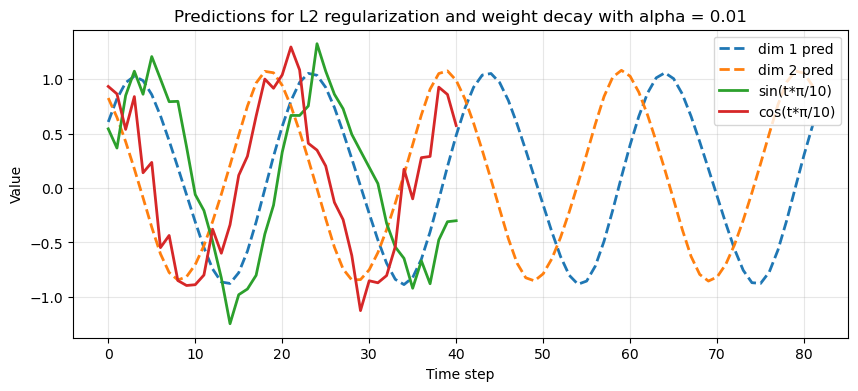

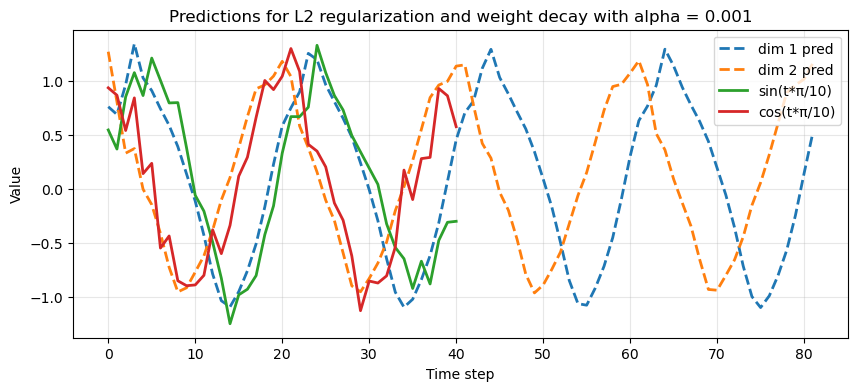

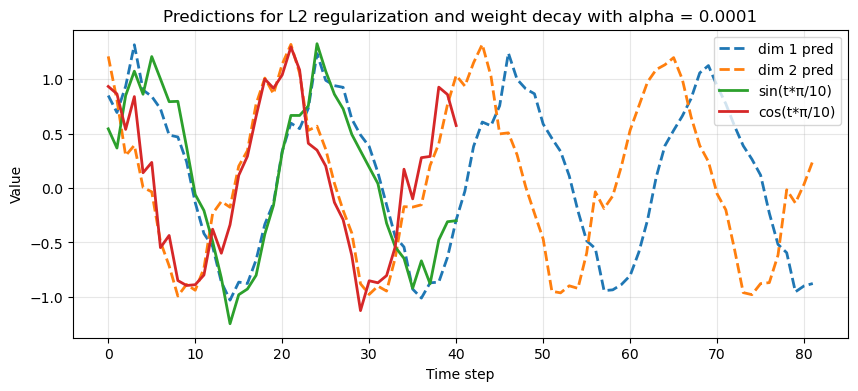

In [108]:
# L2 regularization function
def l2_reg(model, alpha):
    
    l2_reg = sum((param**2).sum() for param in model.parameters())
    reg_term = alpha * l2_reg

    return reg_term

# Train
alphas = [0.1, 0.01, 0.001, 0.0001]
for alpha in alphas:
    
    model = LatentRNN(observation_size, hidden_size)
    model, losses = train(model, learning_rate, hidden_size, epochs, regularization_fn = l2_reg, alpha=alpha)
    
    # Plot prediction
    prediction_length = 2 * data.shape[0]
    title = f'Predictions for L2 regularization and weight decay with alpha = {alpha}'
    plot_prediction(model, prediction_length, title)

L2 regularization adds the sum of squared weights to the loss, which penalizes large parameter values more heavily than smaller ones. This constraint discourages any single weight from influencing the output too much. So the learned function is smoother and less sensitive to small fluctuations in the input. This reduces overfitting.

2. c)

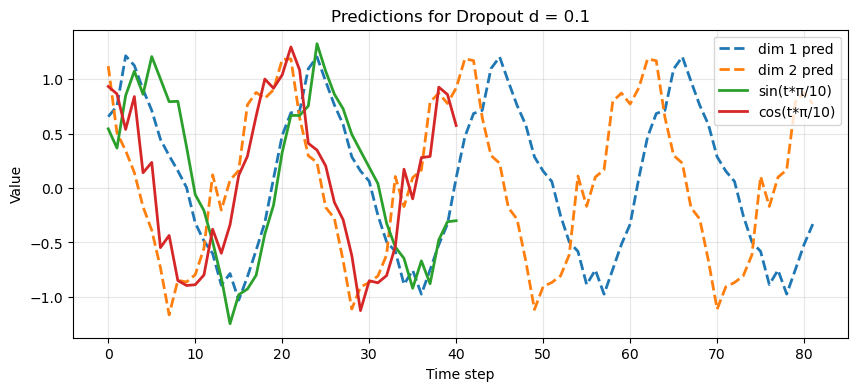

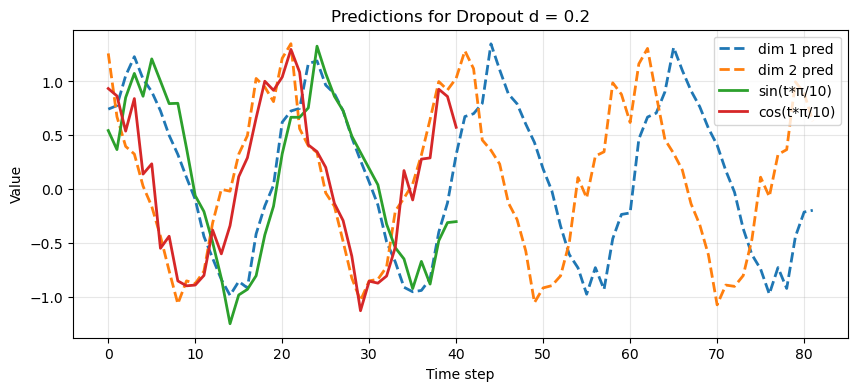

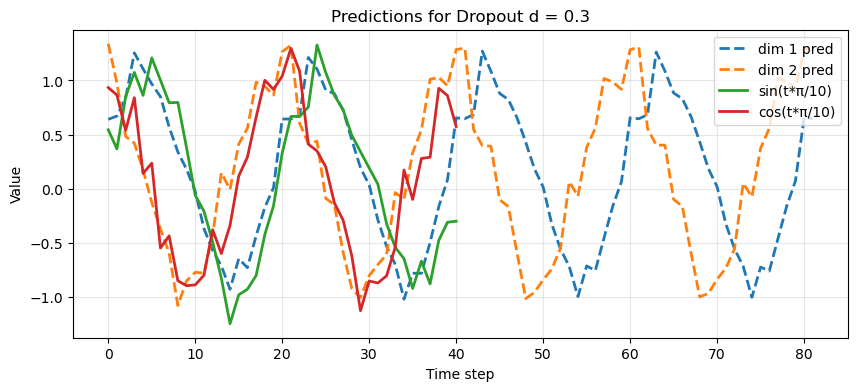

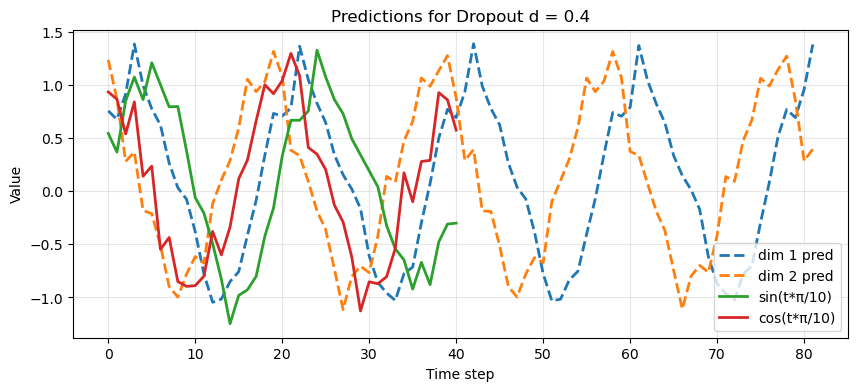

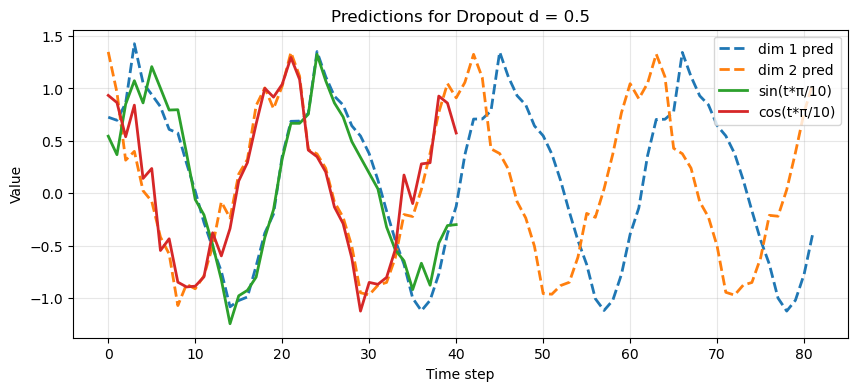

In [109]:
# Apply dropout
dropouts = [0.1, 0.2, 0.3, 0.4, 0.5]
for dropout in dropouts:
    
    model = LatentRNN(observation_size, hidden_size, dropout=dropout)
    model, losses = train(model, learning_rate, hidden_size, epochs)
    
    # Plot prediction
    prediction_length = 2 * data.shape[0]
    title = f'Predictions for Dropout d = {dropout}'
    plot_prediction(model, prediction_length, title)

Dropout randomly sets a fraction of activations to zero during each training step, removing subsets of neurons for this step. This prevents units from adapting too strongly to one another and forces each neuron to learn representations that are useful in different subnetworks. At inference time, all neurons are active, which has the effect of averaging across many networks. This decreases overfitting